# Capstone Three: Online Shopper Purchase Intent

## Pre-processing and Model Development 

### Capstone Objective

The objective of this capstone project is to develop and compare machine learning models that predicts whether an online shopping session will result in a purchase. The final selected model is intended to support e-commerce conversion optimization by identifying visitors with higher purchase intent based on their browsing behavior and session characteristics.

Three models will be evaluated: a logistic regression baseline, a random forest model, and a feedforward deep neural network. The traditional machine
learning models will provide benchmarks against which the performance of the neural network can be assessed.

Because only 15.5% of sessions result in a purchase, model performance will be evaluated using precision, recall, F1-score, and ROC-AUC in addition to
accuracy. Particular attention will be given to the model's ability to identify purchasing sessions.

### Import Libraries 

In [3]:
# Import libraries 
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

#Install kagglehub
%pip install kagglehub

#Install tensorflow
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub

# Download latest version of the data
path = kagglehub.dataset_download("henrysue/online-shoppers-intention")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abhi\.cache\kagglehub\datasets\henrysue\online-shoppers-intention\versions\1


In [5]:
import os

os.listdir(path)

['online_shoppers_intention.csv']

### Load Dataset

In [7]:
df = pd.read_csv(os.path.join(path, "online_shoppers_intention.csv"))

In [8]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [9]:
df.shape

(12330, 18)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

##### Dataset

The Online Shoppers Purchasing Intention dataset was obtained directly from Kaggle using the KaggleHub API. The dataset contains 12,330 shopping sessions
and 18 variables, including 17 predictor variables and the binary `Revenue` target variable.

The dataset was reloaded in this notebook rather than using a preprocessed CSV from the previous notebook. All transformations in this notebook will be fit using the training data only to prevent data leakage.

### Define Features and Target

In [13]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"].astype(int)

In [14]:
# Confirm shape of X
X.shape

(12330, 17)

In [15]:
# Confirm shape of y
y.shape

(12330,)

In [16]:
y.value_counts()

Revenue
0    10422
1     1908
Name: count, dtype: int64

### Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
# Confirm that the train/test split was successful 
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (9864, 17)
Test set: (2466, 17)

Training target distribution:
Revenue
0    0.845296
1    0.154704
Name: proportion, dtype: float64

Test target distribution:
Revenue
0    0.845093
1    0.154907
Name: proportion, dtype: float64


##### Observations from Train/Test Split

The dataset was divided into 80% training data (9,864 observations) and 20% test data (2,466 observations). Stratified sampling was used to preserve the
proportion of purchasing and non-purchasing sessions in both subsets.

The resulting class distributions are highly consistent between the training and test sets, with approximately 84.5% non-purchasing and 15.5% purchasing
sessions in each.

### Identify Feature Types

In [22]:
# Create lists for numerical features 
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

In [23]:
# Create lists for categorical features 
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

In [24]:
# Create lists for boolean features 
boolean_features = [
    "Weekend"
]

In [25]:
# Confirm that we captured all the required features 
all_features = numeric_features + categorical_features + boolean_features

print("Total features:", len(all_features))
print("Features in X:", X.shape[1])
print("All features accounted for:", set(all_features) == set(X.columns))

Total features: 17
Features in X: 17
All features accounted for: True


### Build pre-processing pipeline 

In [27]:
# Import the relevant tools 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [28]:
# Create the transformer 
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features),
        ("bool", "passthrough", boolean_features)
    ]
)

### Transform Training and Test Data 

In [30]:
# Fit the preprocessor ONLY on the training data 
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [31]:
# Confirm that the transformer worked correctly 
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (9864, 17)
Processed training shape: (9864, 74)
Original test shape: (2466, 17)
Processed test shape: (2466, 74)


In [32]:
# Get the resulting feature names 
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print(feature_names)

Number of processed features: 74
['num__Administrative' 'num__Administrative_Duration' 'num__Informational'
 'num__Informational_Duration' 'num__ProductRelated'
 'num__ProductRelated_Duration' 'num__BounceRates' 'num__ExitRates'
 'num__PageValues' 'num__SpecialDay' 'cat__Month_Aug' 'cat__Month_Dec'
 'cat__Month_Feb' 'cat__Month_Jul' 'cat__Month_June' 'cat__Month_Mar'
 'cat__Month_May' 'cat__Month_Nov' 'cat__Month_Oct' 'cat__Month_Sep'
 'cat__OperatingSystems_1' 'cat__OperatingSystems_2'
 'cat__OperatingSystems_3' 'cat__OperatingSystems_4'
 'cat__OperatingSystems_5' 'cat__OperatingSystems_6'
 'cat__OperatingSystems_7' 'cat__OperatingSystems_8' 'cat__Browser_1'
 'cat__Browser_2' 'cat__Browser_3' 'cat__Browser_4' 'cat__Browser_5'
 'cat__Browser_6' 'cat__Browser_7' 'cat__Browser_8' 'cat__Browser_9'
 'cat__Browser_10' 'cat__Browser_11' 'cat__Browser_12' 'cat__Browser_13'
 'cat__Region_1' 'cat__Region_2' 'cat__Region_3' 'cat__Region_4'
 'cat__Region_5' 'cat__Region_6' 'cat__Region_7' 'cat__R

##### Observations on pre-processing 

1. The original dataset contains 17 predictor variables. After preprocessing, the 10 numerical variables were standardized, the six categorical variables
were one-hot encoded, and the Boolean `Weekend` variable was retained as a binary feature. This resulted in 74 model-ready features.
2. The increase from 17 to 74 features is primarily due to one-hot encoding the categorical variables. The same fitted preprocessing transformer will be used to transform future observations during model deployment.
3. Considering the `PageValues` feature: 
- During EDA, `PageValues` was identified as a potentially important predictor of purchase outcome. The dataset documentation defines `PageValues` as the average value of pages visited by a user before completing an e-commerce transaction.
- The original research associated with this dataset and subsequent analyses have used `PageValues` as a predictive feature, and multiple studies have identified it as an important predictor of purchase behavior. Therefore, it will be retained in the initial model rather than excluded solely because of its relationship to transaction activity.
- However, the timing of when `PageValues` becomes available during an individual shopping session may affect its usefulness for an early-intervention use case. This limitation will be acknowledged when interpreting the model and its potential business application. If time permits, a sensitivity analysis excluding `PageValues` will be conducted to evaluate how much model performance depends on this feature. 

### Model 0.0 - Baseline Logistic Regression 

Logistic Regression will be used as the baseline classification model for predicting whether an online shopping session results in a purchase.

Although the primary objective of this capstone is to develop a deep neural network, establishing a simple baseline provides a reference point for
evaluating whether the more complex models provide meaningful improvements in predictive performance.

Logistic Regression is appropriate for this problem because `Revenue` is a binary response variable. It also provides a relatively interpretable
benchmark against which the nonlinear Random Forest and neural network models can be compared.

In [35]:
# Import relevant tools 
from sklearn.linear_model import LogisticRegression

In [36]:
# Fit the model 
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
# Generate class predictions 
y_pred_lr = logreg.predict(X_test_processed)

#Generate probability predictions 
y_prob_lr = logreg.predict_proba(X_test_processed)[:, 1]

##### Observations on Model Evaluation Metrics

Because only approximately 15.5% of sessions in the dataset result in a purchase, accuracy alone may provide a misleading assessment of model
performance. A model that predicts every session as non-purchasing would achieve approximately 84.5% accuracy while failing to identify any purchasing
sessions. 
Therefore, model performance will primarily be evaluated using precision, recall, F1-score, and ROC-AUC. Accuracy will also be reported as a secondary
metric.
- **Precision:** Of the sessions predicted to result in a purchase, the
  proportion that actually resulted in a purchase.
- **Recall:** Of the sessions that actually resulted in a purchase, the
  proportion correctly identified by the model.
- **F1-score:** The harmonic mean of precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish purchasing from
  non-purchasing sessions across classification thresholds.
- **Accuracy:** The proportion of all sessions classified correctly.

In [39]:
# Import relevant libraries and tools 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [40]:
# Evaluate the model
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {lr_accuracy:.3f}")
print(f"Precision: {lr_precision:.3f}")
print(f"Recall   : {lr_recall:.3f}")
print(f"F1 Score : {lr_f1:.3f}")
print(f"ROC-AUC  : {lr_auc:.3f}")

Accuracy : 0.881
Precision: 0.741
Recall   : 0.359
F1 Score : 0.483
ROC-AUC  : 0.883


In [41]:
# Generate classification report 
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



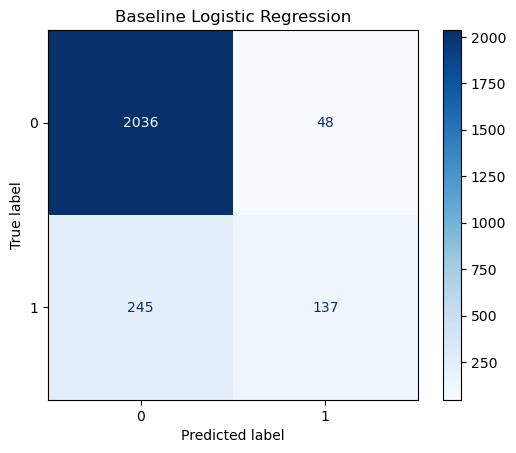

In [42]:
# Plot the confusion matrix 
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Baseline Logistic Regression")
plt.show()

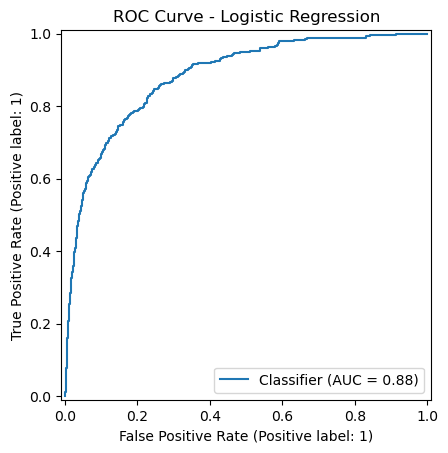

In [43]:
# Plot the ROC curve 
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

##### Observations from the baseline logistic regression model 

1. The Logistic Regression baseline achieved an accuracy of 88.1% and a ROC-AUC of 0.883, indicating that the model has a relatively strong ability to distinguish between purchasing and non-purchasing sessions.
2. The model achieved relatively high precision for purchasing sessions (74.1%) but substantially lower recall (35.9%). This indicates that when the model predicts a purchase, it is frequently correct, but it identifies only a portion of the sessions that ultimately result in a purchase.
3. The classification report shows a substantial difference in performance between the two classes. Recall was 98% for non-purchasing sessions compared with 36% for purchasing sessions, reflecting the impact of the imbalanced target variable.
4. The difference between the relatively strong ROC-AUC and lower purchase recall at the default classification threshold suggests that the model contains useful predictive information but is conservative when assigning the purchase class.
5. Logistic Regression provides a useful baseline against which the more flexible Random Forest and deep neural network models can be compared.

In [45]:
# Store Logistic Regression results for model comparison
logreg_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [lr_accuracy],
    "Precision": [lr_precision],
    "Recall": [lr_recall],
    "F1 Score": [lr_f1],
    "ROC-AUC": [lr_auc]
})

logreg_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.881184,0.740541,0.358639,0.483245,0.883037


### Model 1.0 - Baseline Random Forest 

Random Forest will be developed as a nonlinear machine learning benchmark against which the Logistic Regression baseline and the deep neural network can
be compared.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions among features without requiring these relationships to be
specified in advance. This is particularly relevant given the skewed behavioral variables and relationships identified during EDA.

A baseline Random Forest will first be evaluated using default model settings. Hyperparameter tuning will then be performed using RandomizedSearchCV on the training data to determine whether model performance can be improved. The held-out test set will remain untouched during tuning and will be used only for final model evaluation.

In [47]:
# Import the relevant tools 
from sklearn.ensemble import RandomForestClassifier

In [48]:
# Initiate the baseline Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [49]:
# Generate class predictions 
y_pred_rf = rf.predict(X_test_processed)

# Generate probability predictions 
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

In [50]:
# Evaluate the model 
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall   : {rf_recall:.3f}")
print(f"F1 Score : {rf_f1:.3f}")
print(f"ROC-AUC  : {rf_auc:.3f}")

Accuracy : 0.900
Precision: 0.766
Recall   : 0.513
F1 Score : 0.614
ROC-AUC  : 0.918


In [51]:
# Generate classification report 
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.77      0.51      0.61       382

    accuracy                           0.90      2466
   macro avg       0.84      0.74      0.78      2466
weighted avg       0.89      0.90      0.89      2466



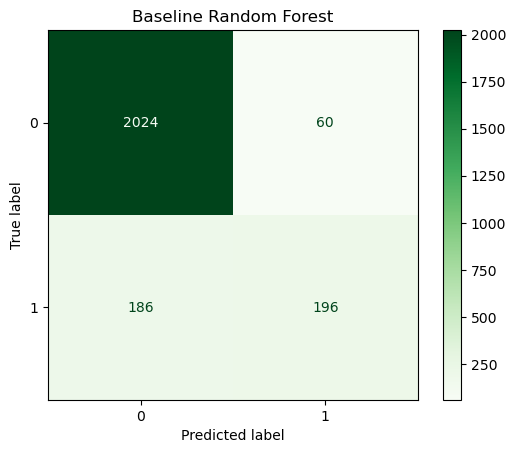

In [52]:
# Plot the confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens"
)

plt.title("Baseline Random Forest")
plt.show()

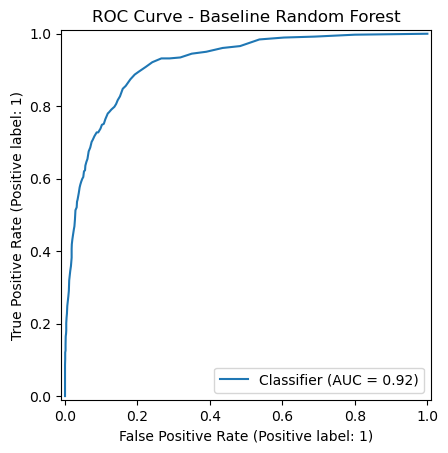

In [53]:
# Plot the ROC curve 
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("ROC Curve - Baseline Random Forest")
plt.show()

##### Observations from the baseline random forest model

1. The baseline Random Forest outperformed the Logistic Regression baseline across all five evaluation metrics. Accuracy increased from 88.1% to 90.0%, while ROC-AUC increased from 0.883 to 0.918.
2. The largest improvement was observed in recall for purchasing sessions, which increased from 35.9% with Logistic Regression to 51.3% with Random Forest. This indicates that the Random Forest was able to identify a larger proportion of sessions that ultimately resulted in a purchase.
3. Precision for the purchase class also improved from 74.1% to 76.6%, indicating that the increase in recall did not come at the expense of substantially more false-positive purchase predictions.
4. The F1-score increased from 0.483 to 0.614, reflecting a stronger balance between precision and recall for the minority purchase class.
5. The Random Forest achieved a recall of 97% for non-purchasing sessions and 51% for purchasing sessions. Although performance remains stronger for the majority class, the Random Forest substantially improves identification of purchasing sessions compared with the Logistic Regression baseline.
6. The results suggest that the nonlinear relationships and feature interactions captured by Random Forest provide additional predictive value beyond the linear Logistic Regression baseline.

In [55]:
# Store baseline random forest results for model comparison
rf_results = pd.DataFrame({
    "Model": ["Baseline Random Forest"],
    "Accuracy": [rf_accuracy],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1 Score": [rf_f1],
    "ROC-AUC": [rf_auc]
})

rf_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Random Forest,0.900243,0.765625,0.513089,0.61442,0.918038


### Model 1.1 Tuned Random Forest 

The baseline Random Forest improved substantially on the Logistic Regression model, particularly in recall and F1-score for purchasing sessions. Hyperparameter tuning will therefore be used to determine whether the Random Forest's performance can be further improved.

The held-out test dataset will not be used during hyperparameter tuning. It will be used only once the best model configuration has been identified.

In [57]:
# Import relevant tools 
from sklearn.model_selection import RandomizedSearchCV

##### Notes on hyperparameter tuning 

RandomizedSearchCV will be used to explore a targeted set of Random Forest hyperparameters using three-fold cross-validation on the training data.

The search is intentionally limited to 10 randomly selected parameter combinations to balance model optimization with computational efficiency.
F1-score is used as the optimization metric because the target variable is imbalanced and the project prioritizes identifying purchasing sessions while maintaining reasonable precision.

In [59]:
# Define the parameter grid
param_grid_rf = {
    "n_estimators": [50, 100, 150],
    "max_depth": [10, 20, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt"],
    "class_weight": [None, "balanced"]
}

In [60]:
# Initiate the RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid_rf,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [61]:
# Fit the RandomizedSearchCV
rf_random_search.fit(X_train_processed, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [10, 20, None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [2, 5],
                                        'min_samples_split': [5, 10],
                                        'n_estimators': [50, 100, 150]},
                   random_state=42, scoring='f1', verbose=1)

In [62]:
# Get the best parameters
print("Best parameters:")
print(rf_random_search.best_params_)

print("\nBest cross-validation F1 score:")
print(f"{rf_random_search.best_score_:.3f}")

Best parameters:
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

Best cross-validation F1 score:
0.681


In [63]:
# Extract the best model
best_rf = rf_random_search.best_estimator_

In [64]:
# Generate class predictions 
y_pred_rf_tuned = best_rf.predict(X_test_processed)

# Generate probability predictions 
y_prob_rf_tuned = best_rf.predict_proba(X_test_processed)[:, 1]

In [65]:
# Evaluate the model 
rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned)
rf_tuned_recall = recall_score(y_test, y_pred_rf_tuned)
rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned)
rf_tuned_auc = roc_auc_score(y_test, y_prob_rf_tuned)

print(f"Accuracy : {rf_tuned_accuracy:.3f}")
print(f"Precision: {rf_tuned_precision:.3f}")
print(f"Recall   : {rf_tuned_recall:.3f}")
print(f"F1 Score : {rf_tuned_f1:.3f}")
print(f"ROC-AUC  : {rf_tuned_auc:.3f}")

Accuracy : 0.893
Precision: 0.644
Recall   : 0.683
F1 Score : 0.663
ROC-AUC  : 0.923


In [66]:
# Generate classification report 
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2084
           1       0.64      0.68      0.66       382

    accuracy                           0.89      2466
   macro avg       0.79      0.81      0.80      2466
weighted avg       0.90      0.89      0.89      2466



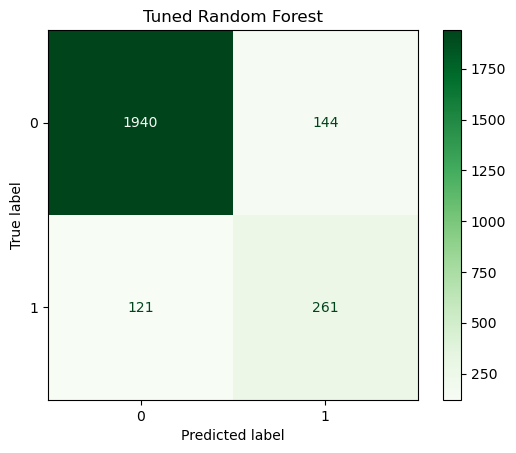

In [67]:
# Plot the confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_tuned,
    cmap="Greens"
)

plt.title("Tuned Random Forest")
plt.show()

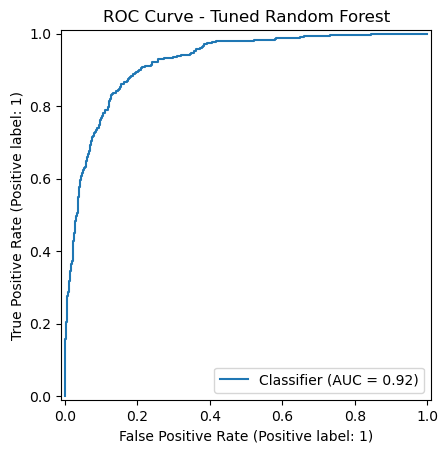

In [68]:
# Plot the ROC curve 
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_tuned
)

plt.title("ROC Curve - Tuned Random Forest")
plt.show()

##### Observations from a tuned random forest model 

1. Hyperparameter tuning improved the Random Forest's ability to identify purchasing sessions. The tuned model achieved a recall of 68.3% for the
   purchase class, compared with 51.3% for the baseline Random Forest.
2. The improvement in recall came with a decrease in precision, from 76.6% to 64.4%. This indicates that the tuned model identifies more potential purchasers but also produces more false-positive purchase predictions.
3. Despite the decrease in precision and overall accuracy, the tuned Random Forest achieved a higher F1-score than the baseline model (0.663 compared
with 0.614). This indicates an improved balance between precision and recall for the minority purchase class.
4. ROC-AUC also improved slightly from 0.918 to 0.923, suggesting that the tuned model maintains strong overall discrimination between purchasing and non-purchasing sessions.
5. The best-performing parameter configuration included `class_weight = "balanced"`, suggesting that accounting for the substantial class imbalance helped the model identify a greater proportion of purchasing sessions.
6. Overall, the tuned Random Forest provides a stronger model for identifying purchasing sessions than the baseline Random Forest when F1-score and recall are prioritized, although this improvement involves a tradeoff with precision and accuracy.

In [70]:
# Store tuned random forest results for model comparison
rf_tuned_results = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [rf_tuned_accuracy],
    "Precision": [rf_tuned_precision],
    "Recall": [rf_tuned_recall],
    "F1 Score": [rf_tuned_f1],
    "ROC-AUC": [rf_tuned_auc]
})

rf_tuned_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.892539,0.644444,0.683246,0.663278,0.922537


## Preparing Training and Validation Data for Deep Neural Networks (DNN)

The neural network requires a validation dataset to monitor model performance during training and support early stopping. To prevent information from the validation set from influencing preprocessing, the original training dataset will first be divided into separate training and validation subsets.

The preprocessing pipeline will then be fit only on the neural network training data and subsequently used to transform the training, validation, and held-out test datasets. This ensures that both the validation and test datasets remain unseen during the preprocessing fitting stage.

In [72]:
# Split the raw training data into NN training and validation sets 
from sklearn.model_selection import train_test_split

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("NN Training set:", X_train_nn.shape)
print("Validation set:", X_val_nn.shape)
print("Test set:", X_test.shape)

NN Training set: (7891, 17)
Validation set: (1973, 17)
Test set: (2466, 17)


In [73]:
# Check class imbalance 
print("NN Training target distribution:")
print(y_train_nn.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val_nn.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

NN Training target distribution:
Revenue
0    0.845267
1    0.154733
Name: proportion, dtype: float64

Validation target distribution:
Revenue
0    0.845413
1    0.154587
Name: proportion, dtype: float64

Test target distribution:
Revenue
0    0.845093
1    0.154907
Name: proportion, dtype: float64


The stratified splits preserve the proportion of purchase and non-purchase sessions across the neural network training, validation, and test datasets. This helps ensure that model performance is evaluated on datasets with similar class distributions.

In [75]:
# Create lists for all features 
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

boolean_features = [
    "Weekend"
]

In [76]:
# Create a separate pre-processor for the neural network
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bool", "passthrough", boolean_features)
    ]
)

In [77]:
# Fit the pre-processor ONLY on the NN training data 
X_train_nn_processed = nn_preprocessor.fit_transform(X_train_nn)

In [78]:
# Transform validation and test data 
X_val_nn_processed = nn_preprocessor.transform(X_val_nn)

X_test_nn_processed = nn_preprocessor.transform(X_test)

In [79]:
# Check the shapes 
print("NN training shape:", X_train_nn_processed.shape)
print("Validation shape:", X_val_nn_processed.shape)
print("Test shape:", X_test_nn_processed.shape)

NN training shape: (7891, 74)
Validation shape: (1973, 74)
Test shape: (2466, 74)


### Model 2.0 - Initial Deep Neural Network

The final model will be a feedforward deep neural network designed to predict whether an online shopping session results in a purchase.

The deep neural network is the primary advanced modeling technique and was selected to evaluate whether a neural network can capture complex nonlinear relationships among browsing behavior, visitor characteristics, traffic sources, and other session-level features.

The model will be trained using the preprocessed training data and evaluated using the same metrics used for the Logistic Regression and Random Forest
models. This allows the performance of the neural network to be compared directly with the established baseline models.

In [81]:
# Import relevant libraries 
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [82]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

# Enable deterministic operations where possible
tf.config.experimental.enable_op_determinism()

In [83]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [84]:
# Verify input shape 
layers.Input(shape=(X_train_nn_processed.shape[1],)),

(<KerasTensor shape=(None, 74), dtype=float32, sparse=False, ragged=False, name=keras_tensor>,)

##### Initial Neural Network Architecture

The initial neural network will use two fully connected hidden layers. The first hidden layer will contain 64 neurons and the second will contain 32
neurons. ReLU activation will be used in the hidden layers, while the output layer will contain a single neuron with sigmoid activation to produce the
probability of a purchase.

Dropout regularization will be included after each hidden layer to reduce the risk of overfitting.

The initial architecture is intentionally modest given the relatively small dataset and the goal of establishing a strong, interpretable deep-learning
baseline before considering additional tuning.

In [86]:
# Create the model 
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_nn_processed.shape[1],)),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
    
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    
    layers.Dense(1, activation="sigmoid")
])

In [87]:
# Print the model summary 
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,913 (27.00 KB)

 Trainable params: 6,913 (27.00 KB)

 Non-trainable params: 0 (0.00 B)

##### Model Training Considerations

The dataset contains approximately 10,000 observations in the development set, while the neural network contains thousands of trainable parameters. This creates a risk of overfitting, where the model learns patterns specific to the training data that do not generalize to new sessions.

Dropout regularization and validation data will therefore be used during training to monitor and reduce overfitting. Early stopping may also be used
to stop training when validation performance stops improving.

In [89]:
# Compile the model 
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [90]:
#Create EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [91]:
# Train the intial NN network 
history = nn_model.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(
        X_val_nn_processed,
        y_val_nn
    ),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8573 - loss: 0.3414 - precision: 0.5971 - recall: 0.2391 - val_accuracy: 0.8860 - val_loss: 0.2708 - val_precision: 0.7410 - val_recall: 0.4033
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8946 - loss: 0.2639 - precision: 0.7490 - recall: 0.4791 - val_accuracy: 0.8890 - val_loss: 0.2590 - val_precision: 0.7172 - val_recall: 0.4656
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8974 - loss: 0.2510 - precision: 0.7381 - recall: 0.5217 - val_accuracy: 0.8920 - val_loss: 0.2507 - val_precision: 0.7000 - val_recall: 0.5279
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9006 - loss: 0.2457 - precision: 0.7409 - recall: 0.5504 - val_accuracy: 0.8951 - val_loss: 0.2492 - val_precision: 0.7059 - val_recall: 0.5508
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9005 - loss: 0.2414 - precision: 0.7280 - recall: 0.5700 - val_accuracy: 0.8971 - val_loss: 0.

In [92]:
# Examine the training history
print("Epochs completed:", len(history.history["loss"]))

Epochs completed: 15


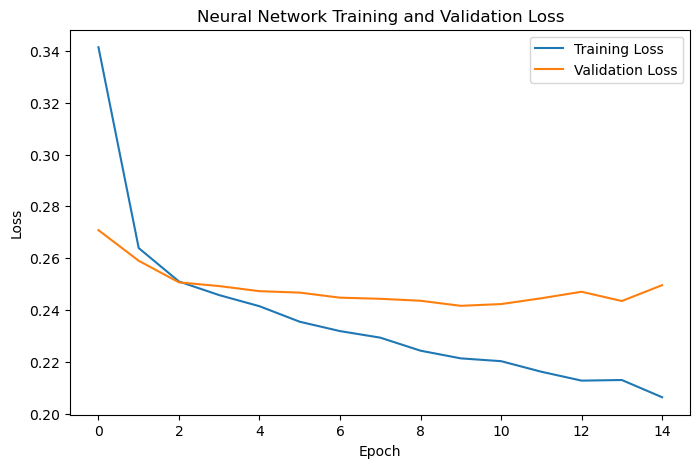

In [93]:
# Plot the training and validation loss  
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training and Validation Loss")
plt.legend()
plt.show()

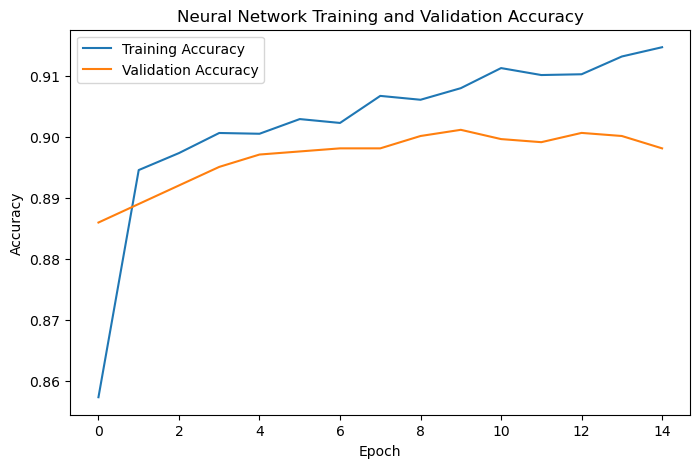

In [94]:
# Plot the training and validation accuracy 
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Training and Validation Accuracy")
plt.legend()
plt.show()

##### Observations

1. The neural network completed 15 of the maximum 50 training epochs before early stopping was triggered. Validation loss improved substantially during the early epochs and reached its lowest value of 0.2416 at Epoch 10. After this point, validation loss generally increased or fluctuated without further improvement.
2. Toward the later epochs, training loss continued to decrease while validation loss stopped improving and began to fluctuate. This suggests the beginning of mild overfitting. Early stopping with `restore_best_weights=True` was therefore useful in retaining the model weights associated with the best validation performance rather than using the weights from the final training epoch.
3. Validation accuracy increased from 88.6% in the first epoch to a peak of 90.1% at Epoch 10 and then remained relatively stable. This suggests that additional training beyond this point did not provide meaningful improvements in overall validation accuracy.
4. Validation recall for the purchasing class increased substantially during training, rising from 40.3% in the first epoch to 61.6% at Epoch 10. This indicates that the neural network became increasingly effective at identifying purchasing sessions as training progressed.
5. Overall, the initial neural network demonstrates useful predictive performance and provides a baseline for evaluating whether changes to the network architecture can improve model performance. The final assessment, however, will be based on performance on the held-out test dataset.

In [96]:
# Initiate the NN model 
y_prob_nn = nn_model.predict(X_test_nn_processed).ravel()

y_pred_nn = (y_prob_nn >= 0.5).astype(int)

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [97]:
# Evaluate the model 
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn)
nn_recall = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)
nn_auc = roc_auc_score(y_test, y_prob_nn)

print(f"Accuracy : {nn_accuracy:.3f}")
print(f"Precision: {nn_precision:.3f}")
print(f"Recall   : {nn_recall:.3f}")
print(f"F1 Score : {nn_f1:.3f}")
print(f"ROC-AUC  : {nn_auc:.3f}")

Accuracy : 0.893
Precision: 0.696
Recall   : 0.552
F1 Score : 0.616
ROC-AUC  : 0.911


In [98]:
# Generate the classification report 
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.70      0.55      0.62       382

    accuracy                           0.89      2466
   macro avg       0.81      0.75      0.78      2466
weighted avg       0.89      0.89      0.89      2466



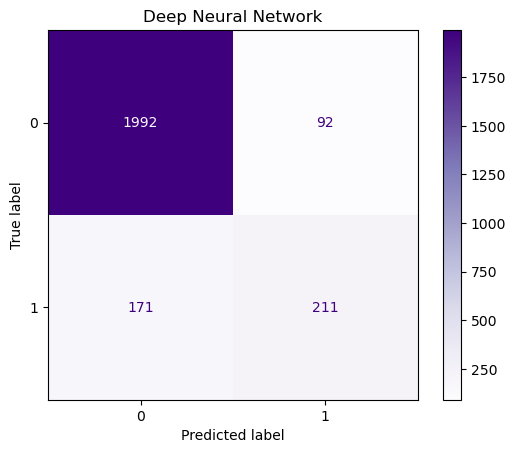

In [99]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nn,
    cmap="Purples"
)

plt.title("Deep Neural Network")
plt.show()

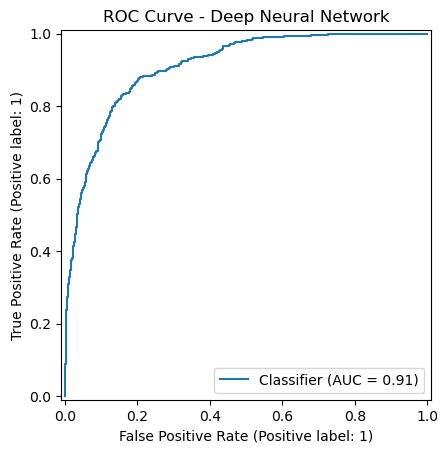

In [100]:
# Plot the ROC curve 
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_nn
)

plt.title("ROC Curve - Deep Neural Network")
plt.show()

In [102]:
# Store NN model results for model comparison
nn_results = pd.DataFrame({
    "Model": ["Initial Deep Neural Network"],
    "Accuracy": [nn_accuracy],
    "Precision": [nn_precision],
    "Recall": [nn_recall],
    "F1 Score": [nn_f1],
    "ROC-AUC": [nn_auc]
})

nn_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Initial Deep Neural Network,0.89335,0.69637,0.552356,0.616058,0.910706


##### Observations from the initial NN model 

1. The initial deep neural network achieved an accuracy of 89.3% and a ROC-AUC of 0.911, demonstrating strong overall predictive performance on the held-out test dataset.
2. The neural network outperformed the Logistic Regression baseline across all five evaluation metrics. In particular, recall for purchasing sessions increased from 35.9% with Logistic Regression to 55.2% with the neural network.
3. The neural network achieved higher precision (69.6%) than the tuned Random Forest (64.4%), indicating that its purchase predictions were more precise at the default 0.5 classification threshold.
4. However, the tuned Random Forest achieved higher recall (68.3%), F1-score (0.663), and ROC-AUC (0.923) than the initial neural network. The tuned Random Forest therefore remains the strongest model based on the current evaluation metrics.
5. The results demonstrate that the neural network captures useful predictive patterns in the data, but its initial architecture does not outperform the tuned Random Forest. The neural network architecture will therefore be further evaluated to determine whether tuning can improve performance without introducing unnecessary model complexity.

### Model 2.1 - Tuned Deep Neural Network

To evaluate whether additional model capacity could improve performance, the neural network architecture was modified by increasing the number of neurons
in the two hidden layers.

The initial neural network used the following architecture:

64 → 32 → 1

The tuned neural network uses:

128 → 64 → 1

All other aspects of the model, including the activation functions, dropout rate, optimizer, loss function, batch size, validation strategy, and early
stopping procedure, were kept consistent. This approach allows the impact of increasing the number of neurons to be evaluated while limiting unnecessary
changes to the model.

##### Tuned Neural Network Architecture

The tuned neural network increases the number of neurons in each hidden layer while maintaining the same two-layer structure used in the initial model.

The architecture consists of:

- Input layer with 74 processed features
- First hidden layer with 128 neurons and ReLU activation
- Dropout layer with a rate of 0.20
- Second hidden layer with 64 neurons and ReLU activation
- Dropout layer with a rate of 0.20
- Output layer with one neuron and a sigmoid activation function for binary
  classification

In [105]:
tf.keras.utils.set_random_seed(42)

In [106]:
# Create the tuned DNN model 
tuned_nn_model = tf.keras.Sequential([
    
    layers.Input(shape=(X_train_nn_processed.shape[1],)),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation="sigmoid")
])

In [107]:
# Print the model summary
tuned_nn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,921 (70.00 KB)

 Trainable params: 17,921 (70.00 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
# Compile the model
tuned_nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [109]:
#Create EarlyStopping 
from tensorflow.keras.callbacks import EarlyStopping

tuned_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [110]:
# Train the tuned NN network 
tuned_nn_history = tuned_nn_model.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(X_val_nn_processed, y_val_nn),
    epochs=50,
    batch_size=32,
    callbacks=[tuned_early_stopping],
    verbose=1
)

Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8791 - loss: 0.3022 - precision: 0.7244 - recall: 0.3530 - val_accuracy: 0.8860 - val_loss: 0.2707 - val_precision: 0.7198 - val_recall: 0.4295
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8965 - loss: 0.2554 - precision: 0.7422 - recall: 0.5070 - val_accuracy: 0.8875 - val_loss: 0.2577 - val_precision: 0.7005 - val_recall: 0.4754
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8996 - loss: 0.2435 - precision: 0.7355 - recall: 0.5487 - val_accuracy: 0.8946 - val_loss: 0.2482 - val_precision: 0.7100 - val_recall: 0.5377
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9036 - loss: 0.2341 - precision: 0.7391 - recall: 0.5823 - val_accuracy: 0.8941 - val_loss: 0.2504 - val_precision: 0.7017 - val_recall: 0.5475
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9022 - loss: 0.2299 - precision: 0.7216 - recall: 0.5987 - val_accuracy: 0.8956 - val_loss: 0.

In [111]:
# Examine the training history
print("Epochs completed:", len(tuned_nn_history.history["loss"]))

Epochs completed: 11


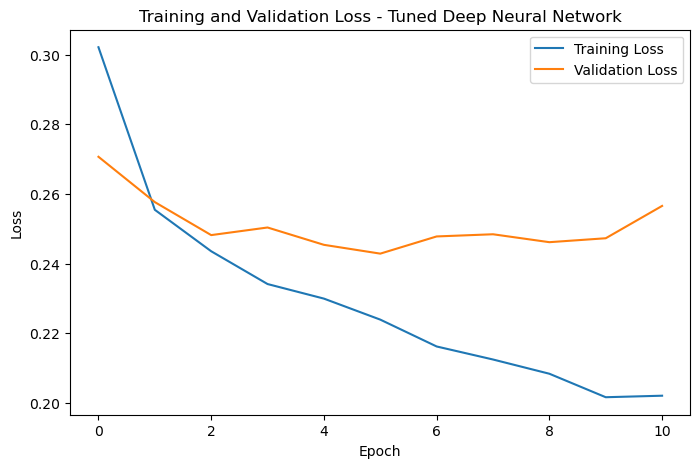

In [112]:
# Plot the training and validation loss 
plt.figure(figsize=(8, 5))

plt.plot(
    tuned_nn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    tuned_nn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - Tuned Deep Neural Network")

plt.legend()

plt.show()

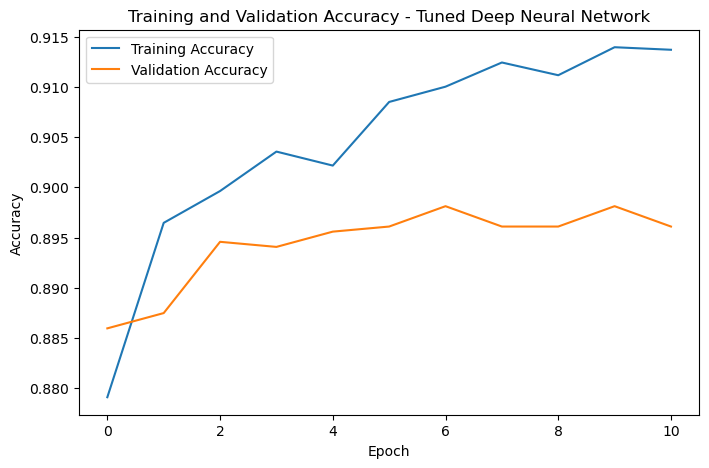

In [113]:
# Plot the training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    tuned_nn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    tuned_nn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy - Tuned Deep Neural Network")

plt.legend()

plt.show()

##### Observations

1. The tuned deep neural network completed 11 training epochs before early stopping was triggered. Validation loss improved substantially during the early epochs and reached its lowest value of 0.2429 at Epoch 6. After this point, validation loss fluctuated and generally worsened.
2. Training loss continued to decrease from 0.302 in the first epoch to 0.202 by the final epoch, while validation loss stopped improving after Epoch 6. This divergence suggests the beginning of mild overfitting. Early stopping with `restore_best_weights=True` was therefore useful in retaining the model weights associated with the best validation loss.
3. Validation accuracy increased from 88.6% in the first epoch to approximately 89.8% by Epochs 7 and 10, after which it remained relatively stable. This suggests that the model's validation performance plateaued relatively early.
4. Validation recall for purchasing sessions increased from 43.0% in the first epoch to approximately 58.0% by Epoch 9. However, this improvement was not accompanied by continued improvement in validation loss, suggesting that the additional model complexity did not substantially improve overall generalization.
5. Compared with the initial deep neural network, increasing the size of the hidden layers from 64 → 32 → 1 to 128 → 64 → 1 did not produce a clear improvement in validation performance. Both models achieved similar validation accuracy and recall levels.
6. Overall, the results suggest that increasing the size of the neural network does not necessarily improve predictive performance for this dataset. The tuned model will next be evaluated on the held-out test dataset to determine whether it provides any improvement over the initial deep neural network and the other models.

### Test Set Evaluation: Tuned Deep Neural Network

The tuned deep neural network will now be evaluated using the held-out test dataset. The same evaluation metrics used for the previous models will be calculated to enable a consistent comparison across all models.

In [116]:
# Generate predicted probabilities
y_prob_tuned_nn = tuned_nn_model.predict(X_test_nn_processed)

# Convert probabilities to binary predictions
y_pred_tuned_nn = (y_prob_tuned_nn >= 0.5).astype(int).flatten()

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [117]:
# Evaluate the tuned deep neural network
tuned_nn_accuracy = accuracy_score(y_test, y_pred_tuned_nn)
tuned_nn_precision = precision_score(y_test, y_pred_tuned_nn)
tuned_nn_recall = recall_score(y_test, y_pred_tuned_nn)
tuned_nn_f1 = f1_score(y_test, y_pred_tuned_nn)
tuned_nn_auc = roc_auc_score(y_test, y_prob_tuned_nn)

print(f"Accuracy : {tuned_nn_accuracy:.3f}")
print(f"Precision: {tuned_nn_precision:.3f}")
print(f"Recall   : {tuned_nn_recall:.3f}")
print(f"F1 Score : {tuned_nn_f1:.3f}")
print(f"ROC-AUC  : {tuned_nn_auc:.3f}")

Accuracy : 0.895
Precision: 0.709
Recall   : 0.542
F1 Score : 0.614
ROC-AUC  : 0.912


In [118]:
# Generate the classification report 
print(classification_report(y_test, y_pred_tuned_nn))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.71      0.54      0.61       382

    accuracy                           0.89      2466
   macro avg       0.81      0.75      0.78      2466
weighted avg       0.89      0.89      0.89      2466



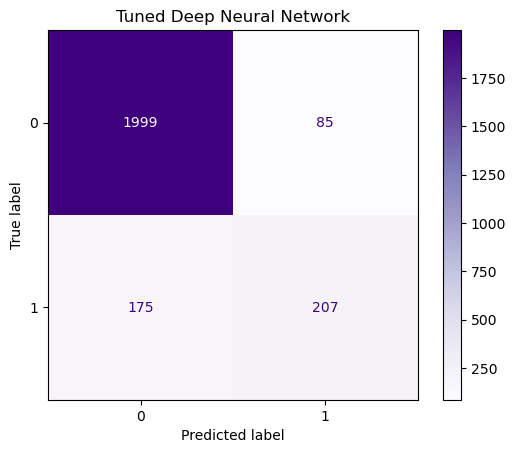

In [119]:
# Plot the confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned_nn,
    cmap="Purples"
)

plt.title("Tuned Deep Neural Network")
plt.show()

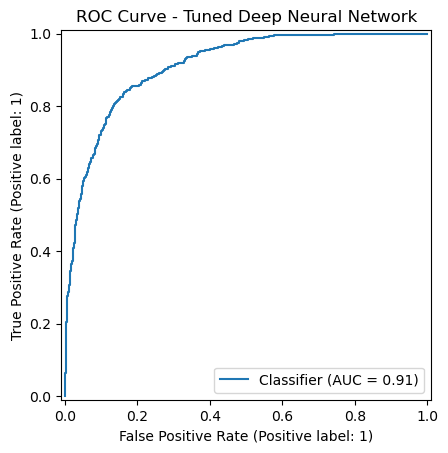

In [120]:
# Plot the ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tuned_nn
)

plt.title("ROC Curve - Tuned Deep Neural Network")
plt.show()

In [121]:
tuned_nn_results = pd.DataFrame({
    "Model": ["Tuned Deep Neural Network"],
    "Accuracy": [tuned_nn_accuracy],
    "Precision": [tuned_nn_precision],
    "Recall": [tuned_nn_recall],
    "F1 Score": [tuned_nn_f1],
    "ROC-AUC": [tuned_nn_auc]
})


tuned_nn_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Deep Neural Network,0.894566,0.708904,0.541885,0.614243,0.912196


##### Observations from the tuned NN model

1. The tuned deep neural network achieved an accuracy of 89.5%, precision of 70.9%, recall of 54.2%, F1 score of 0.614, and ROC-AUC of 0.912 on the held-out test dataset.
2. Compared with the initial deep neural network, the tuned model achieved slightly higher accuracy and precision. Accuracy increased from 89.3% to 89.5%, while precision increased from 69.6% to 70.9%.
3. However, the tuned model achieved slightly lower recall, decreasing from 55.2% in the initial neural network to 54.2%. This indicates that the larger network identified a slightly smaller proportion of actual purchasing sessions.
4. The F1 scores of the two neural network models were nearly identical, with the initial model achieving an F1 score of 0.616 and the tuned model achieving an F1 score of 0.614. The tuned model achieved a slightly higher ROC-AUC of 0.912 compared with 0.911 for the initial neural network.
5. Overall, increasing the complexity of the neural network architecture from 64 → 32 → 1 to 128 → 64 → 1 produced only marginal differences in performance. The tuned model achieved slightly higher accuracy, precision, and ROC-AUC, while the initial model achieved slightly higher recall and F1 score.
6. These results suggest that the larger neural network architecture did not produce a substantial improvement over the initial model. Both neural network models demonstrated similar predictive performance, and neither outperformed the tuned Random Forest, which remained the strongest model based on recall, F1 score, and ROC-AUC.

### Model Comparison

This section compares the performance of the models developed in this project:

- Logistic Regression
- Baseline Random Forest
- Tuned Random Forest
- Initial Deep Neural Network
- Tuned Deep Neural Network

Each model is evaluated using the same held-out test dataset and the same evaluation metrics: accuracy, precision, recall, F1-score, and ROC-AUC. Comparing the models using a consistent evaluation framework allows for an assessment of the trade-offs between overall predictive performance and the ability to correctly identify purchasing sessions.

Because the response variable is moderately imbalanced, accuracy alone is not sufficient for selecting the final model. Particular attention will therefore be given to precision, recall, F1-score, and ROC-AUC when selecting the final model.

In [124]:
#Concactenate all the evaluation metrics 
model_results = pd.concat(
    [
        logreg_results,
        rf_results,
        rf_tuned_results,
        nn_results,
        tuned_nn_results
    ],
    ignore_index=True
)

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.881184,0.740541,0.358639,0.483245,0.883037
1,Baseline Random Forest,0.900243,0.765625,0.513089,0.614420,0.918038
2,Tuned Random Forest,0.892539,0.644444,0.683246,0.663278,0.922537
3,Initial Deep Neural Network,0.893350,0.696370,0.552356,0.616058,0.910706
4,Tuned Deep Neural Network,0.894566,0.708904,0.541885,0.614243,0.912196


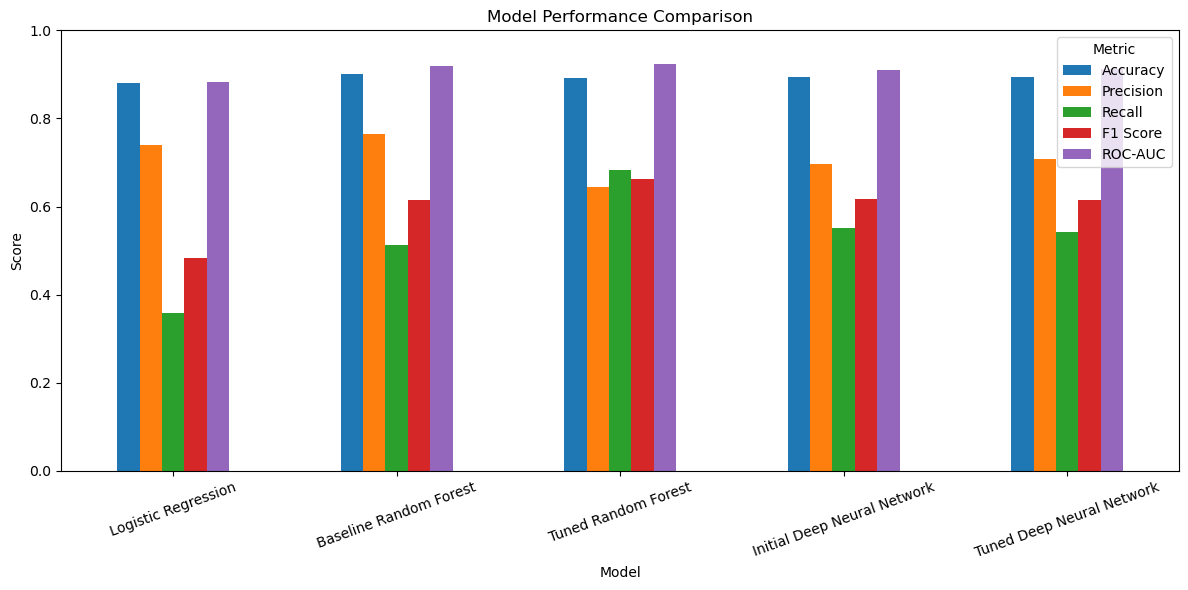

In [125]:
# Graph out the evaluation metrics 
import matplotlib.pyplot as plt

# Set Model as the index for plotting
model_results_plot = model_results.set_index("Model")

# Plot model performance metrics
model_results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

##### Observations from Model Comparison

1. The Tuned Random Forest achieved the highest F1-score (0.663) and ROC-AUC (0.923) among all five models, indicating the strongest overall performance based on the selected evaluation metrics.

2. The Tuned Random Forest also achieved the highest recall (68.3%), meaning that it correctly identified a larger proportion of actual purchasing sessions than any of the other models.

3. The Baseline Random Forest achieved the highest accuracy (90.0%) and precision (76.6%). However, its recall was substantially lower than that of the Tuned Random Forest (51.3% compared with 68.3%), indicating that it missed more actual purchasing sessions.

4. Logistic Regression achieved relatively high precision (74.1%) but had the lowest recall (35.9%) and F1-score (0.483). This suggests that although its predicted purchasing sessions were relatively reliable, it failed to identify a large proportion of actual purchasers.

5. The two deep neural network models achieved very similar performance. The Initial Deep Neural Network achieved slightly higher recall (55.2% compared with 54.2%) and F1-score (0.616 compared with 0.614), while the Tuned Deep Neural Network achieved slightly higher accuracy (89.5% compared with 89.3%), precision (70.9% compared with 69.6%), and ROC-AUC (0.912 compared with 0.911).

6. Overall, increasing the complexity of the neural network architecture produced only marginal differences in performance. The Tuned Deep Neural Network did not demonstrate a substantial improvement over the Initial Deep Neural Network.

7. Overall, the Tuned Random Forest provides the strongest balance between identifying purchasing sessions and maintaining overall predictive performance. Although it has lower precision and accuracy than the Baseline Random Forest, it achieves substantially higher recall and the highest F1-score and ROC-AUC. Based on the project objective and the importance of identifying likely purchasers, the Tuned Random Forest is the strongest candidate for the final model.

### Final Model Selection

The five models developed in this project were compared using accuracy, precision, recall, F1-score, and ROC-AUC. While accuracy provides an overall measure of correct classifications, the response variable is moderately imbalanced, with purchasing sessions representing approximately 15.5% of the dataset. Therefore, accuracy alone is not sufficient for selecting the final model.

The final model selection considers the trade-offs between precision and recall, with particular emphasis on F1-score and ROC-AUC. Recall is also important because the project aims to identify online shopping sessions that are likely to result in a purchase. A model that achieves high accuracy but fails to identify a substantial proportion of actual purchasers would be less useful for this objective.

Based on these criteria, the Tuned Random Forest was selected as the final model. Although the Baseline Random Forest achieved higher accuracy and precision, the Tuned Random Forest achieved substantially higher recall (68.3%), along with the highest F1-score (0.663) and ROC-AUC (0.923) of all models evaluated. This indicates that it provided the strongest overall balance between identifying purchasing sessions and maintaining predictive performance.

### Random Forest - Feature Importance

Although the Tuned Random Forest was selected as the final model based on its predictive performance, it is also important to understand which features contributed most to the model's predictions.

Random Forest models can provide estimates of feature importance based on the extent to which individual features contribute to reducing impurity across the decision trees in the forest. Examining feature importance can provide insight into the characteristics of online shopping sessions that are most useful for distinguishing between purchasing and non-purchasing sessions.

The following analysis examines the relative importance of the features used by the Tuned Random Forest model.

In [129]:
# Feature selection - Select the top 15 performing features 
feature_names = preprocessor.get_feature_names_out()

# Extract feature importances from the tuned Random Forest
feature_importances = rf_random_search.best_estimator_.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort from most to least important
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
8,num__PageValues,0.375405
7,num__ExitRates,0.102848
5,num__ProductRelated_Duration,0.076996
4,num__ProductRelated,0.060935
6,num__BounceRates,0.053684
1,num__Administrative_Duration,0.044834
0,num__Administrative,0.040971
17,cat__Month_Nov,0.025891
3,num__Informational_Duration,0.018551
2,num__Informational,0.013640


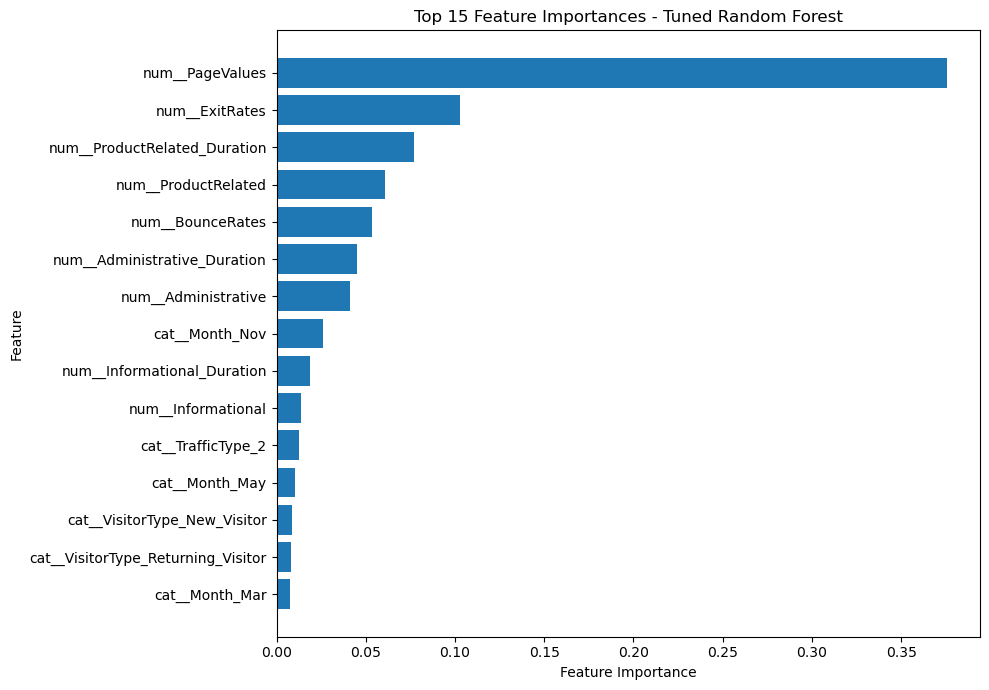

In [130]:
# Plot the 15 most important features
top_features = feature_importance_df.head(15)

# Plot feature importance
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Tuned Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##### Observations from Feature Importance

1. `PageValues` was by far the most important feature in the Tuned Random Forest model, with an importance score of 0.375. Its importance was substantially higher than that of any other feature, indicating that it contributed the most to the model's ability to distinguish between purchasing and non-purchasing sessions.

2. `ExitRates` was the second most important feature (0.103), followed by `ProductRelated_Duration` (0.077), `ProductRelated` (0.061), and `BounceRates` (0.054). These results indicate that measures related to user engagement and browsing behavior were important for predicting whether an online shopping session resulted in a purchase.

3. The importance of `ProductRelated` and `ProductRelated_Duration` suggests that both the number of product-related pages visited and the amount of time spent viewing those pages provided useful information for the model's predictions. This is consistent with the exploratory analysis, which showed meaningful relationships between deeper website engagement and purchasing behavior.

4. Administrative activity was also influential. `Administrative_Duration` (0.045) and `Administrative` (0.041) both appeared among the most important features, suggesting that engagement with administrative pages provided additional predictive information about user behavior during an online shopping session.

5. Several categorical variables appeared among the top features, including `Month_Nov` (0.026), `TrafficType_2` (0.012), `Month_May` (0.010), and visitor type indicators. However, their importance was considerably lower than that of the leading numerical engagement features.

6. Overall, the feature importance results suggest that behavioral characteristics of the browsing session, particularly `PageValues`, exit behavior, and engagement with product-related pages, were more influential in the model's predictions than temporal or visitor classification variables.

7. Feature importance indicates the relative contribution of each feature to the Random Forest model but does not indicate the direction of the relationship or establish causality. Therefore, these results should be interpreted as indicators of predictive usefulness rather than evidence that changes in a particular feature directly cause a customer to make a purchase.

### Model Deployment Preparation

The final stage of this project is to prepare the selected model for deployment. The Tuned Random Forest was selected as the final model based on its strong overall performance, achieving the highest F1-score and ROC-AUC among the models evaluated.

For deployment, it is necessary to preserve both the trained model and the preprocessing steps used during model development. New data must undergo the same transformations, including numerical scaling and categorical encoding, before predictions can be generated.

The fitted preprocessing pipeline and final Tuned Random Forest model will therefore be saved so that they can be reused during deployment.

In [133]:
# Assign the final selected model
final_model = rf_random_search.best_estimator_

# Display the final mode
final_model

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=150, n_jobs=-1, random_state=42)

In [134]:
# Verify the final model can generate predictions
sample_predictions = final_model.predict(
    X_test_processed[:5]
)

print("Sample predictions:", sample_predictions)

Sample predictions: [0 0 1 0 0]


### Saving the Model Artifacts

The fitted preprocessing pipeline and final Tuned Random Forest model are saved separately using `joblib`. During deployment, incoming data will first be passed through the saved preprocessor before being provided to the trained model.

In [136]:
import os
import joblib

# Define the folder where deployment artifacts will be saved
model_dir = r"C:\Users\Abhi\Desktop\DataScienceCapstoneThree\Model"

# Create the folder if it does not already exist
os.makedirs(model_dir, exist_ok=True)

# Define file paths
preprocessor_path = os.path.join(
    model_dir,
    "online_shoppers_preprocessor.pkl"
)

model_path = os.path.join(
    model_dir,
    "online_shoppers_rf_model.pkl"
)

# Save the fitted preprocessor
joblib.dump(
    preprocessor,
    preprocessor_path
)

print("Preprocessor saved successfully.")

# Save the final Random Forest model
joblib.dump(
    final_model,
    model_path
)

print("Final model saved successfully.")

Preprocessor saved successfully.
Final model saved successfully.


In [137]:
# Verify that the files were created
print(
    "Preprocessor file exists:",
    os.path.exists(preprocessor_path)
)

print(
    "Model file exists:",
    os.path.exists(model_path)
)

Preprocessor file exists: True
Model file exists: True


### Verifying Saved Model Artifacts

To verify that the saved artifacts can be successfully used during deployment, the preprocessing pipeline and trained model are reloaded and used to generate predictions on sample data from the test set.

In [139]:
# Load the saved preprocessor and model
loaded_preprocessor = joblib.load(
    preprocessor_path
)

loaded_model = joblib.load(
    model_path
)

# Transform sample raw data
sample_data = X_test.iloc[:5]

sample_data_processed = loaded_preprocessor.transform(
    sample_data
)

# Generate predictions
loaded_predictions = loaded_model.predict(
    sample_data_processed
)

print("Predictions from loaded model:")
print(loaded_predictions)

Predictions from loaded model:
[0 0 1 0 0]


In [140]:
# Save the original input feature names
input_features = X_train.columns.tolist()

print(
    "Number of required input features:",
    len(input_features)
)

print("\nRequired input features:")

for feature in input_features:
    print(feature)

Number of required input features: 17

Required input features:
Administrative
Administrative_Duration
Informational
Informational_Duration
ProductRelated
ProductRelated_Duration
BounceRates
ExitRates
PageValues
SpecialDay
Month
OperatingSystems
Browser
Region
TrafficType
VisitorType
Weekend


In [141]:
# Define the input features file path
input_features_path = os.path.join(
    model_dir,
    "online_shoppers_input_features.pkl"
)

# Save the input feature names
joblib.dump(
    input_features,
    input_features_path
)

print("Input feature names saved successfully.")

Input feature names saved successfully.


### Deployment Preparation Summary

The Tuned Random Forest model was selected as the final model based on its overall predictive performance. Among the models evaluated, it achieved the highest F1-score and ROC-AUC while also identifying the largest proportion of purchasing sessions.

To prepare the model for deployment, the fitted preprocessing pipeline and final trained Random Forest model were saved as reusable artifacts. The original input feature names were also preserved to ensure that future data contains the same predictors used during model development.

The saved deployment workflow follows the sequence:

**New Session Data → Preprocessing Pipeline → Feature Transformation → Tuned Random Forest Model → Purchase Prediction**

The saved artifacts were successfully reloaded and used to generate predictions from raw test data, confirming that the preprocessing and prediction workflow can be reproduced outside of the model development environment.

These artifacts are now prepared for integration into an appropriate deployment environment, where users can provide new online shopping session characteristics and receive a prediction indicating whether the session is likely to result in a purchase.